# 03 — Product Profitability Analysis

Revenue alone isn't enough - this notebook looks at margin and builds the high/low-sales x high/low-profit quadrant view from the spec.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from db import get_engine

sns.set_theme(style="whitegrid")
engine = get_engine()
pd.options.display.float_format = '{:,.2f}'.format


## Revenue, profit, and margin per product

In [2]:
products = pd.read_sql('''
    SELECT p.product_id, p.product_name, p.category,
           SUM(o.quantity) AS units_sold,
           SUM(o.quantity * p.selling_price * (1 - o.discount)) AS revenue,
           SUM(o.quantity * p.unit_cost) AS cost
    FROM orders o JOIN products p ON p.product_id = o.product_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY p.product_id, p.product_name, p.category
''', engine)
products['profit'] = products['revenue'] - products['cost']
products['margin_pct'] = (products['profit'] / products['revenue'] * 100).round(1)
products.sort_values('profit', ascending=False).head(10)


,product_id,product_name,category,units_sold,revenue,cost,profit,margin_pct
48,P1017,Samsung Laptops Vel,Electronics,75,"4,865,668.78","3,037,992.75","1,827,676.03",37.60
130,P1023,Dell Mobiles Incidunt,Electronics,101,"5,113,478.86","3,323,722.14","1,789,756.72",35.00
14,P1002,Apple Laptops Eaque,Electronics,68,"4,073,770.88","2,642,319.52","1,431,451.36",35.10
40,P1008,Portronics Laptops Iusto,Electronics,74,"3,596,627.08","2,441,095.72","1,155,531.36",32.10
138,P1005,HP Accessories Eveniet,Electronics,66,"2,911,345.20","1,792,878.12","1,118,467.08",38.40
50,P1018,Sony Audio Voluptatem,Electronics,56,"2,735,335.76","1,709,551.76","1,025,784.00",37.50
129,P1019,Sony Audio Quia,Electronics,76,"3,746,316.03","2,898,070.00","848,246.03",22.60
88,P1013,Lenovo Audio Tenetur,Electronics,71,"3,467,307.89","2,636,697.89","830,610.00",24.00
119,P1020,Anker Mobiles Quo,Electronics,66,"2,529,381.88","1,706,416.14","822,965.74",32.50
123,P1004,Xiaomi Audio Adipisci,Electronics,48,"2,735,030.76","1,967,005.44","768,025.32",28.10


## High/low sales x high/low profit quadrant

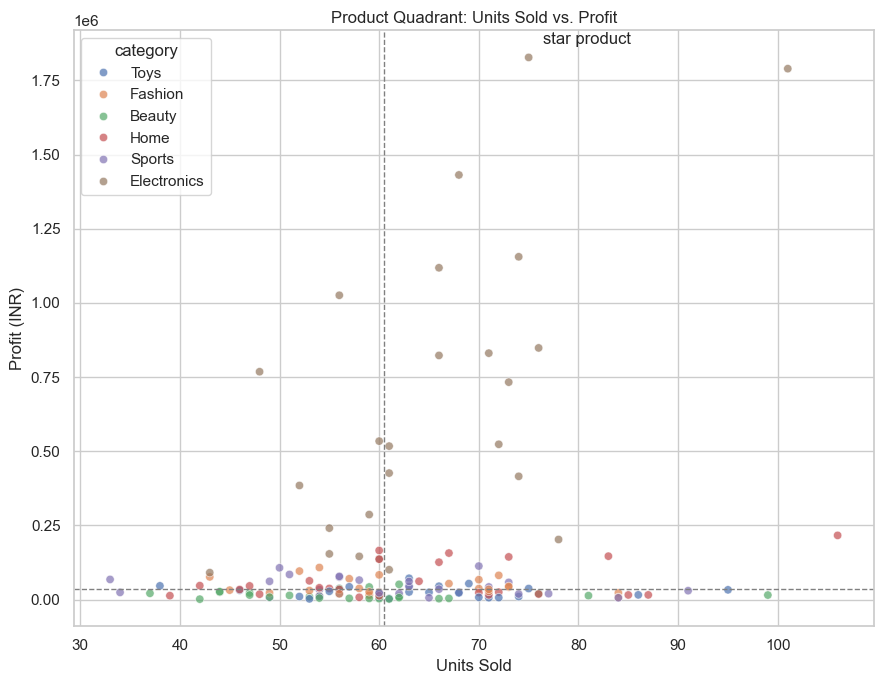

High sales / High profit: 40 products
High sales / Low profit:  35 products
Low sales / High profit:  35 products
Low sales / Low profit:   40 products


In [3]:
sales_median = products['units_sold'].median()
profit_median = products['profit'].median()

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=products, x='units_sold', y='profit', hue='category', alpha=0.7, ax=ax)
ax.axvline(sales_median, color='gray', linestyle='--', linewidth=1)
ax.axhline(profit_median, color='gray', linestyle='--', linewidth=1)
ax.set_title('Product Quadrant: Units Sold vs. Profit')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Profit (INR)')

best = products.loc[products['profit'].idxmax()]
ax.annotate('star product', xy=(best['units_sold'], best['profit']),
            xytext=(10, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f"High sales / High profit: {((products.units_sold >= sales_median) & (products.profit >= profit_median)).sum()} products")
print(f"High sales / Low profit:  {((products.units_sold >= sales_median) & (products.profit <  profit_median)).sum()} products")
print(f"Low sales / High profit:  {((products.units_sold <  sales_median) & (products.profit >= profit_median)).sum()} products")
print(f"Low sales / Low profit:   {((products.units_sold <  sales_median) & (products.profit <  profit_median)).sum()} products")


## Revenue leader vs. profit leader (the PDF's Product A vs Product B scenario, with real data)

In [4]:
revenue_leader = products.sort_values('revenue', ascending=False).iloc[0]
profit_leader = products.sort_values('profit', ascending=False).iloc[0]
print("Revenue leader:", revenue_leader['product_name'], f"- revenue INR {revenue_leader['revenue']:,.0f}, profit INR {revenue_leader['profit']:,.0f}")
print("Profit leader: ", profit_leader['product_name'], f"- revenue INR {profit_leader['revenue']:,.0f}, profit INR {profit_leader['profit']:,.0f}")


Revenue leader: Dell Mobiles Incidunt - revenue INR 5,113,479, profit INR 1,789,757
Profit leader:  Samsung Laptops Vel - revenue INR 4,865,669, profit INR 1,827,676
